# Exploratory Data Analysis of Adopted Cats

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

path = Path.cwd()
while not (path / 'data').exists():
    path = path.parent
os.chdir(path)
print(os.getcwd())

c:\Users\annam\OneDrive\Desktop\TKH\Phase 1 Project - Individual


In [10]:
# inspect the cleaned data
df = pd.read_parquet('data/clean/clean_cats_data.parquet')
df.head(5)


,id,sex,sizeUOM,ageGroup,ageString,breedString,colorDetails,pictureCount,videoCount,adoptedDate,...,isSpecialNeeds,isDeclawed,ownerExperience,obedienceTraining,adultSexesOk,energyLevel,exerciseNeeds,vocalLevel,sheddingLevel,length_of_stay
2,10000193,Male,NaN,Adult,8 Years 8 Months,Domestic Short Hair / Mixed,NaN,5,0,2016-08-13 00:00:00+00:00,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.0
9,10000236,Female,Pounds,Adult,10 Years 6 Months,Domestic Short Hair (short coat),NaN,4,0,2016-06-25 00:00:00+00:00,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.0
10,10000242,Female,Pounds,Baby,6 Years 8 Months,Domestic Short Hair (short coat),White w/calico,2,0,2016-05-28 00:00:00+00:00,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0
11,10000252,Female,Pounds,Baby,6 Years 8 Months,Domestic Short Hair (short coat),Tabby w/white,2,0,2016-05-28 00:00:00+00:00,...,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.0
20,10000959,Male,Pounds,Adult,NaN,Domestic Short Hair (short coat),NaN,1,0,2016-06-11 00:00:00+00:00,...,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0


In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 11929 entries, 2 to 149827
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     11929 non-null  str                
 1   sex                    11821 non-null  str                
 2   sizeUOM                9751 non-null   str                
 3   ageGroup               10915 non-null  str                
 4   ageString              11420 non-null  str                
 5   breedString            11929 non-null  str                
 6   colorDetails           3568 non-null   str                
 7   pictureCount           11929 non-null  int64              
 8   videoCount             11929 non-null  int64              
 9   adoptedDate            11929 non-null  datetime64[us, UTC]
 10  isCurrentVaccinations  7679 non-null   object             
 11  newPeopleReaction      5349 non-null   str                
 12  sizeC

## Columns with the least available data to analyze:
    ownerExperience
    obedienceTraining
    exerciseNeeds
    vocalLevel
    sheddingLevel

These fields can still be evaluated against our dependent variable, but our analysis will be more precise if we analyze correlations of length_of_stay with other cat characteristics.

In [12]:
# Analyze the dataframe's quantitative variables
df.describe()

,pictureCount,videoCount,sizeCurrent,length_of_stay
count,11929.000000,11929.000000,4643.000000,11929.000000
mean,2.803085,0.055327,5.229440,74.283846
std,2.453294,0.318432,3.746718,203.906184
min,0.000000,0.000000,0.500000,0.000000
25%,1.000000,0.000000,2.815000,8.000000
50%,2.000000,0.000000,4.000000,24.000000
75%,4.000000,0.000000,7.000000,62.000000
max,25.000000,8.000000,99.599998,3672.000000


Length of stay ranges anywhere from 0 days to 3672 days. Ordering the dataset by least to most days of stay, the middle 50% of cats took anywhere between 8-62 days to be adopted as of becoming available. Seventy-five percent were adopted in 2 months or less, with the median taking 24 days. 

In [13]:
Q1 = df['length_of_stay'].quantile(0.25)
Q3 = df['length_of_stay'].quantile(0.75)

IQR = Q3 - Q1
lower_boundary = Q1-1.5*IQR
upper_boundary = Q3+1.5*IQR

print("Identifying Outliers---")
print("Lower Boundary: ",lower_boundary)
print("Upper Boundary: ",upper_boundary)

outliers_df = df[df['length_of_stay'] > upper_boundary]
outliers_df.info()


Identifying Outliers---
Lower Boundary:  -73.0
Upper Boundary:  143.0
<class 'pandas.DataFrame'>
Index: 1223 entries, 32 to 142650
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   id                     1223 non-null   str                
 1   sex                    1212 non-null   str                
 2   sizeUOM                1011 non-null   str                
 3   ageGroup               1143 non-null   str                
 4   ageString              1200 non-null   str                
 5   breedString            1223 non-null   str                
 6   colorDetails           356 non-null    str                
 7   pictureCount           1223 non-null   int64              
 8   videoCount             1223 non-null   int64              
 9   adoptedDate            1223 non-null   datetime64[us, UTC]
 10  isCurrentVaccinations  909 non-null    object             
 11 

Out of a total 11,929 cats, 1,223 had an outlier number of days spent in adoption. These records need to be considered before diving into machine learning for this dataset.

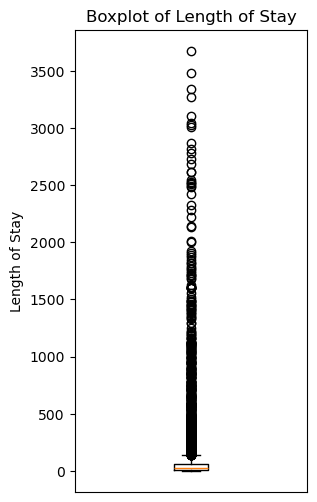

In [14]:
plt.figure(figsize=(3, 6))
plt.boxplot(df['length_of_stay'])

plt.ylabel('Length of Stay')
plt.title('Boxplot of Length of Stay')
plt.xticks([])
plt.show()

The box plot visualizes the data set's extreme outliers.

In [15]:
df['breedString'].describe()

count                                11929
unique                                 714
top       Domestic Short Hair (short coat)
freq                                  2853
Name: breedString, dtype: object

While there are 714 different uniquely described breeds in the data, the domestic short hair, short coat cat breed makes up ~24% of the adopted cats.

In [16]:
pivot_df = df['breedString'].value_counts().to_frame('Count of Cats')
pivot_df.index.name = 'Breed'
print("Sorted By Frequency:")
pivot_df.head(10)

Sorted By Frequency:


,Count of Cats
Breed,
Domestic Short Hair (short coat),2853
Domestic Short Hair / Mixed (short coat),1634
Domestic Short Hair / Mixed,1060
Domestic Short Hair,909
Domestic Medium Hair (medium coat),517
Domestic Short Hair / Tabby / Mixed (short coat),292
Domestic Long Hair (long coat),215
Domestic Short Hair / Tabby (short coat),176
Domestic Medium Hair / Mixed,174


The top 4 most common breeds of adopted cats have short hair, making up ~54% of all the cats- as opposed to long or medium haired breeds.

In [17]:
df['sheddingLevel'].value_counts().to_frame()

,count
sheddingLevel,
Moderate,2290
None,21
High,19


There is less variety in shedding levels to analyze than anticipated- with almost all animals shedding a moderate amount.

In [18]:
df['sizeGroup'].describe()

count       7722
unique         4
top       Medium
freq        4554
Name: sizeGroup, dtype: object

In [19]:
df['sizeGroup'].value_counts().to_frame()

,count
sizeGroup,
Medium,4554
Small,2486
Large,632
X-Large,50


A vast majority of cats assigned a size group label are small or medium.

In [20]:
df['sizeUOM'].value_counts().to_frame()

,count
sizeUOM,
Pounds,9740
Ounces,9
Kilograms,1
Centimeters,1


If checking the correlation of size versus length of stay, we'd need to modify or filter out the few rows that have a different unit of measurement for size

In [21]:
df['sizeCurrent'].value_counts().to_frame()

,count
sizeCurrent,
3.00,591
2.00,521
4.00,349
5.00,237
8.00,232
...,...
12.20,1
4.99,1
14.72,1


In [22]:
lb_df = df[df['sizeUOM'] == 'Pounds']
lb_df['sizeCurrent'].sort_values(ascending=False).to_frame()

,sizeCurrent
80788,99.599998
135899,29.000000
1533,28.000000
52022,22.000000
43371,21.580000
...,...
142650,NaN
147351,NaN
148822,NaN
149502,NaN


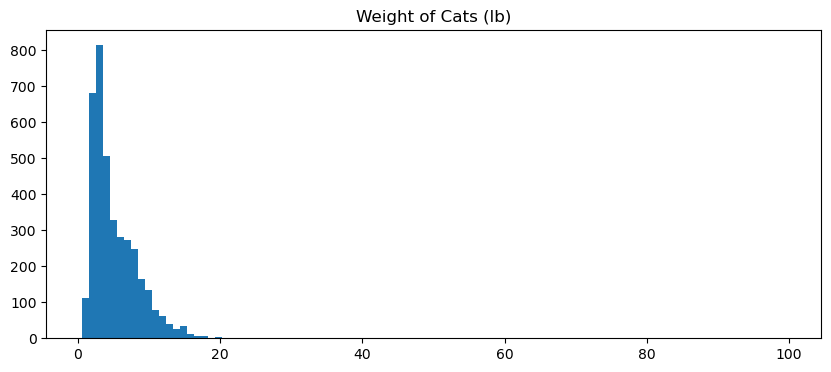

In [23]:
plt.figure(figsize=(10, 4))
plt.hist(lb_df['sizeCurrent'], bins=100)

plt.title('Weight of Cats (lb)')
plt.show()

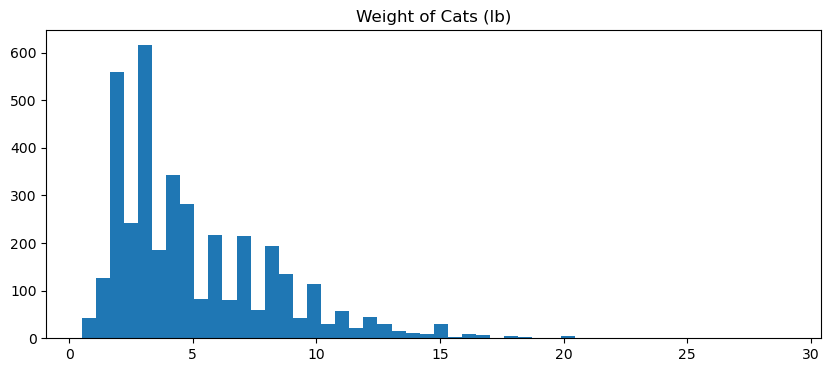

In [24]:
#  Excluding the single 99lb cat to zoom in on the rest of the data

lb_filtered_df = lb_df[lb_df['sizeCurrent'] < 99]

plt.figure(figsize=(10, 4))
plt.hist(lb_filtered_df['sizeCurrent'], bins=50)

plt.title('Weight of Cats (lb)')
plt.show()

Average adult cat weighs between 8-12 pounds, with most weighing around 10 (petmd). Since a majority of cats in the data are below that range, there may be a lot of younger or malnourished cats.

PetMD: https://www.petmd.com/cat/general-health/average-weight-cats

In [25]:
df['ageGroup'].value_counts()

ageGroup
Baby      5360
Young     3020
Adult     2379
Senior     156
Name: count, dtype: int64

A further look shows that most of the adopted cats in our data are indeed young or baby cats.

## Summary

**Next Step**
Wait for Phase 2 to apply new correlation analysis concepts.